# SM 2

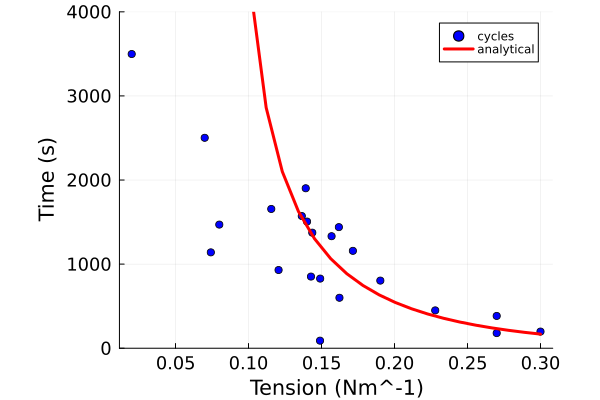

In [1]:
using DataFrames
using DelimitedFiles
using StatsPlots; gr()
using Plots
using Base.Threads


k_on_0 = 3.47e-4
k_off_0 = 2.68e-4 
f_1e = 2.49e-1

# import utility functions
include("src/utils.jl");

# import functions that help calculate stability equilibria
include("src/f_vectors_k_vectors_nvectors.jl");
# This function return variables that act as look-up tables for stability that can be used by functions of f_vectors_k_vectors_nvectors.jl
K, F, n_stable_store, n_unstable_store = setup_stores(k_off_0 / k_on_0);

# import functions that define loading patterns
include("src/loading_patterns.jl");

# import functions that define the analytical model
include("src/analytical_model.jl");

filename = "data/processed_data.csv"

# Read the data
data, header = readdlm(filename, ',', header=true)
df_data = DataFrame(data, vec(Symbol.(header)));
df_data.t_gamma_high = df_data.t_gamma_high .* 60;  # convert minutes to seconds
df_data.gamma_high = df_data.gamma_high ./ 1e4;  # convert to N/m

df_plot = filter(row -> row.label in (1, 0), df_data)
# Create the plot explicitly (not inside @df)
p = scatter(df_plot.gamma_high, df_plot.t_gamma_high;
    xlabel = "Gamma high (N/m)",
    ylabel = "t* (s)",
    guidefont = font(14), 
    title = "",
    left_margin = 10Plots.mm,
    right_margin = 10Plots.mm,
    legend = false,
    xtickfont = font(12),
    ytickfont = font(12),
    size = (570, 300),
    label = "cycles",
    ylims = (0, 4000),
    color="blue"
)


duration = 15000
gamma_high = range(0.09, 0.3, length=20)

# fracture time
time_to_fracture = get_fracture_time.(gamma_high, k_on_0, k_off_0, f_1e, duration)
plot!(p, gamma_high, time_to_fracture, label="analytical", linewidth=3, color=:red)
plot!(p, xlabel="Tension (Nm^-1)", ylabel="Time (s)", legend=:topright, title="", titlefontsize=16, size=(600, 400), ylims=(0, 4000))

display(p)

Parameter fitting -> long runtime

In [2]:
using Interpolations
using Optim    

tension = filter(row -> row.label in (1, 0), df_data).gamma_high
fracture = filter(row -> row.label in (1, 0), df_data).t_gamma_high

tension_avg = mean(filter(row -> row.label in (1), df_data).gamma_high)
fracture_time_avg = mean(filter(row -> row.label in (1), df_data).t_gamma_high)

function error_constrained_tension_at_0_15(params, weight_mean_rmse = 3.0)
    try
        k_on_0 = exp(params[1])
        k_off_0 = exp(params[2])
        f_1e = exp(params[3])

        fracture_duration = 4000
        gamma_high =  1 .* exp10.(range(-5, stop=1, length=100))
        time_to_fracture = @suppress get_fracture_time.(gamma_high, k_on_0, k_off_0, f_1e, fracture_duration)  # add gamma_low initialise at stable eq of gamma_low

        # remove values that are smaller than 0.05
        gamma_high = gamma_high[time_to_fracture .> 0.05]
        time_to_fracture = time_to_fracture[time_to_fracture .> 0.05]

        # remove deplicates if any in the time_to_fracture, in first element of the array
        time_to_fracture = unique(time_to_fracture)
        # Remove corresponding gamma_high values from the start of the gamma_hgh array
        gamma_high = gamma_high[end-length(time_to_fracture)+1:end]

        if length(gamma_high) < 2 # only one datapoint
            return 1000.    # large value that will not be a minimum
        end

        # find gamma_high of model for which the time to fracture equals fracture time of experiment
        # Perform linear interpolation
        interpolation = LinearInterpolation(time_to_fracture[end:-1:1], gamma_high[end:-1:1], extrapolation_bc=Line())
        rmse_creep = (sum((interpolation(fracture) .- tension).^2) / length(tension))^0.5
        rse_mean = ((interpolation(fracture_time_avg) - tension_avg)^2)^0.5
        return rmse_creep + weight_mean_rmse * rse_mean
    catch
        return 1000      # large value that will not be a minimum
    end
end


error_constrained_tension_at_0_15 (generic function with 2 methods)

In [ ]:
p1 = 3 .*exp10.(range(-5, stop=-3, length=3))
p2 = 3 .*exp10.(range(-5, stop=-3, length=3))
p3 = 5.5 .*exp10.(range(-3, stop=-1, length=5))

error_fn = error_constrained_tension_at_0_15

params_grid = [[p1[i], p2[j], p3[k]] for i in 1:length(p1), j in 1:length(p2), k in 1:length(p3)]
results = zeros(7, length(params_grid))
n_sim = length(params_grid)
res = nothing
@threads for idx in 1:1:n_sim
    params0 = params_grid[idx]
    res = optimize(error_fn, log.(params0), NelderMead(), Optim.Options(iterations=500, show_trace = false))
    results[1:3, idx] = params0
    results[4:6, idx] = exp.(Optim.minimizer(res))
    results[7, idx] = Optim.minimum(res)
end

# Find the best result
best_result = argmin(results[7, :])
best_params = results[4:6, best_result]
best_rmse = results[7, best_result]
best_init = results[1:3, best_result]

println("Best parameters: ", exp.(best_params))
println("Best RMSE: ", best_rmse)
println("Best init: ", best_init)


# SM 3

In [14]:
using CellAdhesion
using Plots
import CellAdhesion: runcluster, BondModel

# Leaf cluster: bonds stacked along y, colored by tension.
function plot_force_distribution!(v::Cluster{Bond{T}}, p, x, y = 0.0, dt = 1.0; cmap = :viridis,
                       show_colorbar::Bool = true, f_1e=1.0) where T <: BondModel
  states = [bond.state for bond in v.u]
  forces = [bond.f for bond in v.u] ./ f_1e
  y_coords = y .+ (0:(v.n - 1)) .* v.l
  closed     = findall(states)
  open_bonds = findall(.!states)

    unit_square(x, y, dt) = Shape(
      [x - dt/2, x + dt/2, x + dt/2, x - dt/2],
      [y - 0.5, y - 0.5, y + 0.5, y + 0.5]
  )


  if !isempty(closed)
    for i in closed
      plot!(p, unit_square(x, y_coords[i], dt);
            fill_z = forces[i],
            seriescolor = cmap,
            linecolor = :transparent,
            colorbar = show_colorbar,
            colorbar_title = "Tension",
            clims = (0.0, maximum(forces)),
            label = "")
    end
  end

  if !isempty(open_bonds)
      for i in open_bonds
          plot!(p, unit_square(x, y_coords[i], dt);
                fillcolor = "#e0e0e0",
                linecolor = :transparent,
                label = "")
      end
  end
end

# Hierarchical cluster: sub-clusters laid out horizontally (different x).
function plot_force_distribution!(v::Cluster, p, x, y, dt; cmap = :viridis, show_colorbar::Bool = true, f_1e=1.0)
  running_y = 0     
  for i = 1:v.n
    plot_force_distribution!(v.u[i], p, x , y + running_y, dt; cmap = cmap, show_colorbar = show_colorbar && i == 1)
    running_y += v.u[i].n * v.u[i].l + v.l
  end
end

# Convenience wrapper that creates the plot and returns it.
function plot_force_distribution(v, p, x, y, dt, cmap, f_1e)
  p = plot!(p, legend = false, framestyle = :box)
  plot_force_distribution!(v, p, x, y, dt; cmap = cmap, f_1e=f_1e)
  xlabel!(p, "time")
  ylabel!(p, "Bond index")
  return p  
end

function runcluster(v::Cluster, force::Vector{Float64}, dt::Float64, file_name::String; max_steps::Integer = 1000, verbose::Bool = false, show_tension=true, f_1e=1.0)

  # Arbitrary force history applied to the junction
  n = length(force)
  if max_steps > n
         @warn max_steps<=n "Maximum number of steps exceed force vector length"
  	 max_steps = n
         print("\n Maximum number of steps = ", max_steps, "\n")
  end
  
  step = 1
  p = plot()
  force = convert(Vector{CellAdhesionFloat},force)
  dt = convert(CellAdhesionFloat, dt)
  while (step <= max_steps) && (v.state == true)
      F = force[step]
      setforce!(v, F)
      if show_tension
        plot_force_distribution(v, p, step*dt, 0, dt, :viridis, f_1e)
      else
        plot_cluster(v, p, step, 0)
      end
      update!(v, dt)
      step = step + 1
  end
  while (step <= max_steps)
    if show_tension
      plot_force_distribution(v, p, step*dt, 0, dt, :viridis, f_1e)
    end
      step = step + 1
  end 
  if verbose == true
      if v.state == false
          print("Junction broken")
      elseif step > max_steps
          print("Maximum number of iterations reached")
      end
  end
  plot!(p, xlims=(0, max_steps*dt), xlabel="Time (s)")
  savefig(p, file_name)
  return v.state, force[step-1], dt*(step-1), (step-1)
end

# Model parameters used throughout the notebooks
k_on_0 = 3.47e-4
k_off_0 = 2.68e-4 
f_1e = 2.49e-1

model = SlipBondModel((k_on_0=k_on_0,), (k_off_0=k_off_0, f_1e=f_1e))
n = convert(CellAdhesionInt, 50)
l = convert(CellAdhesionFloat, 1.0)
max_steps = 100
# Single-cluster demo
v1 = Cluster(n, l, model, :force_local)
force = repeat([0.095 * n], max_steps)

runcluster(v1, force, 60.0, "force_local.svg"; max_steps = max_steps, verbose = false, f_1e=f_1e)

v1 = Cluster(n, l, model, :force_global)
runcluster(v1, force, 60.0, "force_global.svg"; max_steps = max_steps, verbose = false, f_1e=f_1e)

(false, 4.75f0, 6000.0f0, 100)

In [ ]:
using Base.Threads
using ProgressBars

# Model parameters used throughout the notebooks
k_on_0 = 3.47e-4
k_off_0 = 2.68e-4 
f_1e = 2.49e-1

# import functions that define loading patterns
include("src/utils.jl");

# import functions that define loading patterns
include("src/loading_patterns.jl");

# import functions that define loading patterns
include("src/analytical_model.jl");

# import functions that define loading patterns
include("src/stochastic_model.jl");

include("src/local_force/stochastic_model.jl");

# import functions that help calculate stability equilibria
include("src/f_vectors_k_vectors_nvectors.jl");
# This function return variables that act as look-up tables for stability that can be used by functions of f_vectors_k_vectors_nvectors.jl
K, F, n_stable_store, n_unstable_store = setup_stores(k_off_0 / k_on_0);


Number of threads: 20


d

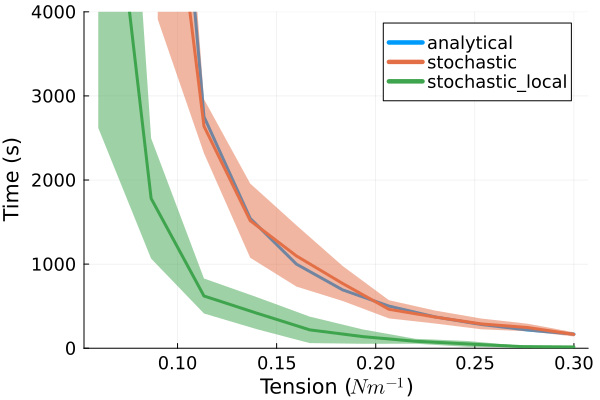

In [ ]:
duration = 15000
gamma_high = range(0.09, 0.3, length=10)
gamma_high_local = range(0.06, 0.3, length=10)

# fracture time
time_to_fracture = get_fracture_time.(gamma_high, k_on_0, k_off_0, f_1e, duration)

time_to_fracture_stochastic = get_fracture_time_stochastic.(gamma_high, k_on_0, k_off_0, f_1e, duration, nothing, 10, 100, false);

time_to_fracture_stochastic_local = get_fracture_time_stochastic_local.(gamma_high_local, k_on_0, k_off_0, f_1e, duration, nothing, 10, 100, false);


plot(gamma_high, time_to_fracture, label="analytical", linewidth=3)
means = [mean(x) for x in time_to_fracture_stochastic]
stds  = [std(x)  for x in time_to_fracture_stochastic]
plot!(gamma_high, means, label="stochastic", ribbon=stds, linewidth=3)
means = [mean(x) for x in time_to_fracture_stochastic_local]
stds  = [std(x)  for x in time_to_fracture_stochastic_local]
plot!(gamma_high_local, means, label="stochastic_local", ribbon=stds, linewidth=3)

plot!(xlabel="Tension (\$Nm^{-1}\$)", ylabel="Time (s)", legend=:topright, title="", titlefontsize=16, size=(600, 400), ylims=(0, 4000), tickfontsize=12, guidefontsize=14, legendfontsize=12)
# savefig("rupture_timescales_local.svg")

c

In [ ]:
duration = 8000
gamma_low = range(0.0, 0.08, length=10);
gamma_local = range(0.0, 0.05, length=10);
dt = 3.0

# analytical recovery time
time_to_recovery = get_recovery_time.(gamma_low, k_on_0, k_off_0, f_1e, duration, true, dt);

# stochastic recovery time
num_sim = 100 # number of simulations to run for each tension value
n = 100
repeats = 5
stochastic_recovery = zeros(repeats, length(gamma_low))
stochastic_recovery_local = zeros(repeats, length(gamma_local))
for i = 1:repeats
    recovery_time = get_recovery_time_stochastic.(gamma_low, k_on_0, k_off_0, f_1e, duration, true, false, dt, num_sim, n);
    stochastic_recovery[i,:] = [x[1] for x in recovery_time]
    recovery_time_local = get_recovery_time_stochastic_local.(gamma_local, k_on_0, k_off_0, f_1e, duration, true, false, dt, num_sim, n);
    stochastic_recovery_local[i,:] = [x[1] for x in recovery_time_local]
end

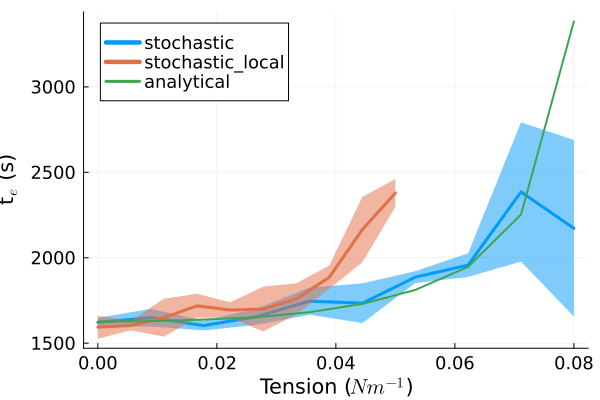

In [ ]:
means = vec(mean(stochastic_recovery, dims=1))
stds  = vec(std(stochastic_recovery, dims=1))

x_recovery = gamma_low isa Number ? collect(range(0.0, 0.08, length=length(means))) : collect(gamma_low)
x_recovery_local = gamma_local isa Number ? collect(range(0.0, 0.05, length=length(means))) : collect(gamma_local)
plot(x_recovery, means, label="stochastic", ribbon=stds, linewidth=3)
means = mean(stochastic_recovery_local, dims=1) |> vec
stds  = std(stochastic_recovery_local, dims=1) |> vec
plot!(x_recovery_local, means, label="stochastic_local", ribbon=stds, linewidth=3)
plot!(x_recovery, time_to_recovery, label="analytical", linewidth=2)
plot!(xlabel="Tension (\$Nm^{-1}\$)", ylabel="t\$_e\$ (s)", legend=:topleft, title="", tickfontsize=12, guidefontsize=14, legendfontsize=12, size=(600, 400))
# savefig("recovery_timescales_local.svg")

f

In [ ]:
gamma_high = 0.09
gamma_low = 0.0175
duration = 20000

num_sim = 100
n = 100
l = 1

time_to_recovery_stochastic = get_recovery_time_stochastic_local(gamma_low, k_on_0, k_off_0, f_1e, duration, false, false, 1.0, num_sim, n)
time_to_fracture_stochastic = get_fracture_time_stochastic_local(gamma_high, k_on_0, k_off_0, f_1e, duration, gamma_low, num_sim, n, true);

# get stable and unstable n at low gamma to initialize cyclic simulations
n_stable, n_unstable = critical_n(k_off_0/k_on_0, gamma_low/f_1e, K, F, n_stable_store, n_unstable_store, true)
n_init = n_stable

# proportional ranges of high and low time periods relative to their respective timescales
time_high_ratio = range(0.01, 1.5, length=40)
time_low_ratio = range(0.01, 4.5, length=40)

# run simulations over grid of time ratios
cyclic_time_to_fracture_stochastic = zeros(length(time_high_ratio), length(time_low_ratio), num_sim)

for t1 in 1:length(time_high_ratio)
    for t2 in ProgressBar(1:length(time_low_ratio))
        # get duration to spend 20x time_to_fracture at high tension for current t_high and t_low
        objective_time_high = 20 * time_to_fracture_stochastic
        t_high = time_high_ratio[t1]*time_to_fracture_stochastic
        t_low = time_low_ratio[t2]*time_to_recovery_stochastic
        period = t_high + t_low
        n_periods = ceil(objective_time_high / t_high)
        duration = n_periods * period

        # set dt to 1/100 of the minimum of time_high and time_low periods for fast simulations
        dt = minimum([t_high, t_low])/100

        # modify dt so that a multiple of dt is equal to the duration
        dt = duration/round(Int, duration/dt)
        
        # define cyclic loading for stochastic model
        loading = square_cycle_uneven_new(gamma_high, gamma_low, t_high, t_low)
        tension_bond, n_timesteps = loading_stochastic_model(loading, n, duration, dt)
        
        @threads for sim = 1:1:num_sim   # number of simulations
            model = SlipBondModel((k_on_0=k_on_0,), (k_off_0=k_off_0, f_1e=f_1e)) 
            x = Cluster(n, l, model, :force_local)
            x = initialise_bonds_state(x, n_init)
            _, _, fracture_time, _ = runcluster(x, tension_bond, dt, max_steps = n_timesteps, verbose=false)
            cyclic_time_to_fracture_stochastic[t1, t2, sim] = fracture_to_t_high(fracture_time, t_high, t_low)
        end
    end
end
# rescale data from 0 to 1
cyclic_time_to_fracture_plot = adjoint(mean(cyclic_time_to_fracture_stochastic, dims=3)[:,:,1])
cyclic_time_to_fracture_plot = (cyclic_time_to_fracture_plot .- time_to_fracture_stochastic) ./ cyclic_time_to_fracture_plot

# Plot heatmap
x = vec(time_high_ratio) .* time_to_fracture_stochastic
y = vec(time_low_ratio) .* time_to_recovery_stochastic
plot(size=(450, 400), guidefontsize=16, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
heatmap!(x./1000,y./1000, cyclic_time_to_fracture_plot, color=:viridis, xlabel="\$t_{high} (10^3 s)\$", ylabel="\$t_{low} (10^3 s)\$", cbar=true, clims=(0, 1))
xlims!(0, maximum(x./1000))
ylims!(0, maximum(y./1000))
savefig("cyclic_local2.svg")
# rescale data from 0 to 1
cyclic_time_to_fracture_plot = adjoint(mean(cyclic_time_to_fracture_stochastic, dims=3)[:,:,1])
cyclic_time_to_fracture_plot = (cyclic_time_to_fracture_plot .- time_to_fracture_stochastic) ./ cyclic_time_to_fracture_plot

# Plot heatmap
x = vec(time_high_ratio) 
y = vec(time_low_ratio) 
plot(size=(450, 400), guidefontsize=16, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
heatmap!(x, y, cyclic_time_to_fracture_plot, color=:viridis, xlabel="\$t_{high} / t^*\$", ylabel="\$t_{low}/t_e\$", cbar=true, clims=(0, 1))
xlims!(0, maximum(x))
ylims!(0, maximum(y))

# SM 4

Critical tension: 0.06484392292819521
Equilibrium for critical tension: 0.138795


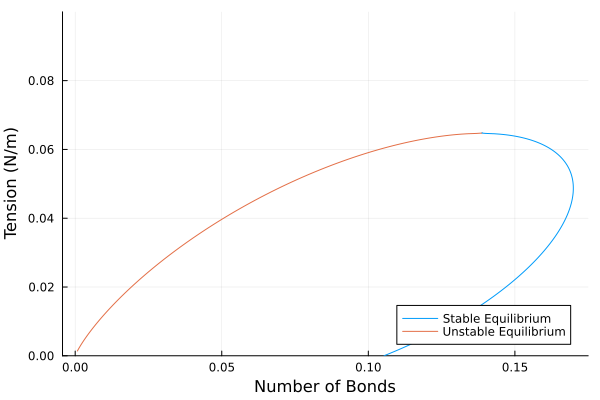

In [ ]:
using Base.Threads
using ProgressBars

# import utility functions
include("src/utils.jl");

# import functions that define loading patterns
include("src/loading_patterns.jl");

# import functions that help calculate stability equilibria
include("src/catchbonds/f_vectors_k_vectors_nvectors.jl");

# import functions that define the analytical model
include("src/catchbonds/analytical_model.jl");

# import functions that define loading patterns
include("src/catchbonds/loading_patterns.jl");

# set single population model parameters
k_on_0 = 3.47e-4
k_off_s = 2.68e-4 
f_1s = 2.49e-1
k_off_c = k_off_s * 10.
f_1c = f_1s;

# get some general info about this population & print critical values
F, n_stable_store, n_unstable_store = setup_stores(k_on_0, k_off_s, k_off_c, f_1s, f_1c)
f_critical, n_critical = critical_f_vector(F, n_stable_store, n_unstable_store)
println("Critical tension: $f_critical")
println("Equilibrium for critical tension: $n_critical")

plot(n_stable_store, F, label="Stable Equilibrium")
plot!(n_unstable_store, F, label="Unstable Equilibrium", ylabel="Tension (N/m)", xlabel="Number of Bonds")
ylims!(0, 0.1)
# savefig("catch_bond_equilibria_par2.svg")

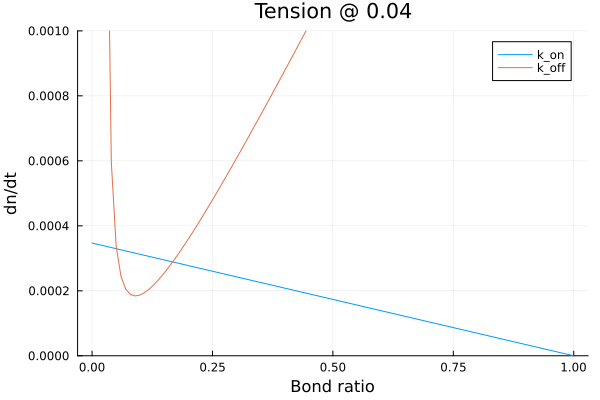

In [ ]:
# Plot kon(n) and koff(n)
n_ratio = 0:0.01:1
tension = 0.04
Gamma = constant_loading(tension)
p = (k_on_0 = k_on_0, k_off_s= k_off_s, f_1s=f_1s, k_off_c= k_off_c, f_1c=f_1c, Gamma=Gamma)
f1_results=[]
f2_results=[]

for n in n_ratio
    f1,f2 = dn_dt_catch_separate(n, p,0.)
    push!(f1_results,f1)
    push!(f2_results,f2)
end

plot(n_ratio,f1_results, label="k_on")
plot!(n_ratio,f2_results, xlabel="Bond ratio", ylabel="dn/dt", ylims=(0,0.001), title= "Tension @ $tension", label="k_off")

    

0.0%┣                                              ┫ 0/40 [00:01<00:-25, -1s/it]
2.5%┣█                                          ┫ 1/40 [00:03<Inf:Inf, InfGs/it]
5.0%┣██▍                                             ┫ 2/40 [00:04<02:25, 4s/it]
7.5%┣███▋                                            ┫ 3/40 [00:04<01:23, 2s/it]
10.0%┣████▊                                          ┫ 4/40 [00:05<01:00, 2s/it]
12.5%┣█████▉                                         ┫ 5/40 [00:05<00:48, 1s/it]
15.0%┣███████                                        ┫ 6/40 [00:06<00:40, 1s/it]
17.5%┣████████▎                                      ┫ 7/40 [00:06<00:33, 1s/it]
20.0%┣█████████▍                                     ┫ 8/40 [00:06<00:29, 1it/s]
22.5%┣██████████▋                                    ┫ 9/40 [00:07<00:26, 1it/s]
25.0%┣███████████▌                                  ┫ 10/40 [00:07<00:23, 1it/s]
27.5%┣████████████▋                                 ┫ 11/40 [00:07<00:20, 1it/s]
30.0%┣█████████████▉        

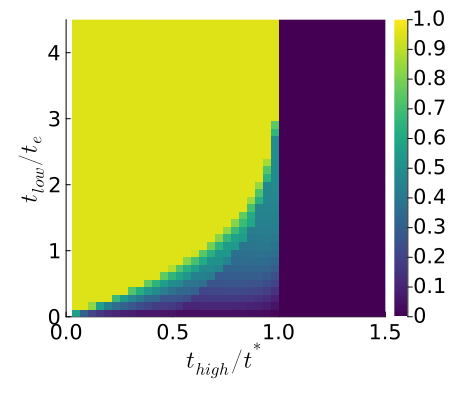

In [ ]:
gamma_high = 0.1
gamma_low = 0.04
duration = 50000

# get stable and unstable n at low gamma to initialize cyclic simulations
n_init, _ = critical_n(gamma_low, F, n_stable_store, n_unstable_store, true)

# get time to recovery
time_to_recovery = get_recovery_time_catch(gamma_low, k_on_0, k_off_s, f_1s, k_off_c, f_1c, 15000.0, false)

# get time to fracture
time_to_fracture = get_fracture_time_catch(gamma_high, k_on_0, k_off_s, f_1s, k_off_c, f_1c, 15000.0, gamma_low, true)

# proportional ranges of high and low time periods relative to their respective timescales
time_high_ratio = range(0.05, 1.5, length=40)
time_low_ratio = range(0.05, 4.5, length=40)

# run simulations over grid of time ratios
cyclic_time_to_fracture = zeros(length(time_high_ratio), length(time_low_ratio))
for t1 in ProgressBar(1:length(time_high_ratio))
    @threads for t2 in 1:length(time_low_ratio)
        # caluclate duration to spend 20x time_to_fracture at high tension for current t_high and t_low
        t_high = time_high_ratio[t1]*time_to_fracture 
        t_low = time_low_ratio[t2]*time_to_recovery
        objective_time_high = 20 *time_to_fracture 
        period = t_high + t_low
        n_periods = ceil(objective_time_high / t_high)
        duration = n_periods * period

        loading = square_cycle_uneven_new(gamma_high, gamma_low, time_high_ratio[t1]*time_to_fracture , time_low_ratio[t2]*time_to_recovery)
        sol = solve_dn_dt_catch(n_init, k_on_0, k_off_s, f_1s, k_off_c, f_1c, loading, duration, 1.0, true)
        fracture_time = find_fracture(sol)
        cyclic_time_to_fracture[t1, t2] = fracture_to_t_high(fracture_time, t_high, t_low) # find how long spent at high tension before fracture                            
    end
end

# Normalised: rescale data from 0 to 1
cyclic_time_to_fracture_plot = adjoint(cyclic_time_to_fracture)
cyclic_time_to_fracture_plot = (cyclic_time_to_fracture_plot .- time_to_fracture) ./ cyclic_time_to_fracture_plot

# Plot heatmap
x = vec(time_high_ratio) #.* time_to_fracture
y = vec(time_low_ratio) #.* time_to_recovery
p1 = plot(size=(450, 400), guidefontsize=16, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
heatmap!(p1, x, y, cyclic_time_to_fracture_plot, color=:viridis, xlabel="\$t_{high}/t^*\$", ylabel="\$t_{low} /t_e\$", cbar=true, clims=(0, 1))
xlims!(p1, 0, maximum(x))
ylims!(p1, 0, maximum(y))
display(p1)
# savefig("catch_cyclic_map_par2.svg")

# SM 8

Number of threads: 20


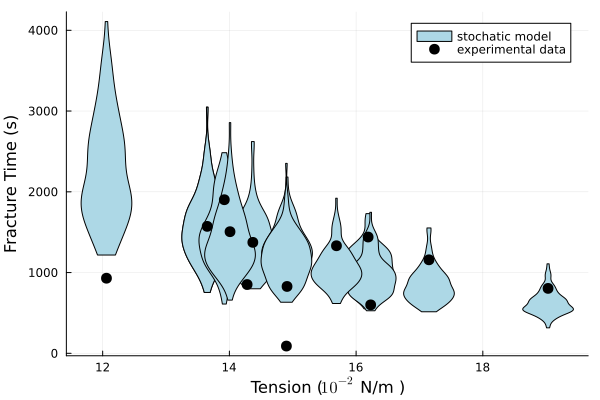

In [4]:
using DelimitedFiles
using Plots
using Measures
using StatsBase
using DataFrames
using StatsPlots; gr()

k_on_0 = 3.47e-4
k_off_0 = 2.68e-4 
f_1e = 2.49e-1

# import utility functions
include("src/utils.jl");

# import functions that help calculate stability equilibria
include("src/f_vectors_k_vectors_nvectors.jl");
# This function return variables that act as look-up tables for stability that can be used by functions of f_vectors_k_vectors_nvectors.jl
K, F, n_stable_store, n_unstable_store = setup_stores(k_off_0 / k_on_0);

# import functions that define loading patterns
include("src/loading_patterns.jl");

# import functions that define the analytical model
include("src/analytical_model.jl");

# import functions that define the stochastic model
include("src/stochastic_model.jl");

filename = "data/processed_data.csv"

# Read the data
data, header = readdlm(filename, ',', header=true)
dataframe = DataFrame(data, vec(Symbol.(header)));
dataframe.t_gamma_high = dataframe.t_gamma_high .* 60;  # convert minutes to seconds
dataframe.gamma_high = dataframe.gamma_high ./ 1e4;  # convert to N/m

fracture_stochastic = get_fracture_time_stochastic.(dataframe.gamma_high[dataframe.label .== 1], k_on_0, k_off_0, f_1e, 20000, nothing, 100, 100, false);

gamma_high = dataframe.gamma_high[dataframe.label .== 1]
expt_t = dataframe.t_gamma_high[dataframe.label .== 1]

violin(stack([gamma_high[:2]])' .* 100, stack(fracture_stochastic[:2]), label="stochatic model", color=:lightblue)
violin!(stack([gamma_high[2:end]])' .* 100, stack(fracture_stochastic[2:end]), label="", color=:lightblue)
scatter!(gamma_high.*100, expt_t, label="experimental data", xlabel="Tension (\$10^{-2}\$ N/m )", ylabel="Fracture Time (s)", color=:black, marker=:circle, markersize=6)
# savefig("exp_sim_creep_violin.svg")

In [5]:
function get_cycles_fracture_time_1000_1000_sto(gamma_high, gamma_low, k_on_0, k_off_0, f_1e, duration)
    loading = square_cycle_uneven_new(gamma_high, gamma_low, 1000, 1000)
    
    n_init = k_on_0/(k_on_0 + k_off_0)
    
    n = 100
    num_sim = 1000
    l=1.0
    dt = 1.0
    tension_bond, n_timesteps = loading_stochastic_model(loading, n, duration, dt)
    sto = zeros(num_sim)
    @threads for sim = 1:1:num_sim   # number of simulations
        model = SlipBondModel((k_on_0=k_on_0,), (k_off_0=k_off_0, f_1e=f_1e)) 
        x = Cluster(n, l, model, :force_global)
        x = initialise_bonds_state(x, n_init)
        _, _, fracture_time, _ = runcluster(x, tension_bond, dt, max_steps = n_timesteps, verbose=false)
        sto[sim] = fracture_to_t_high(fracture_time, 1000, 1000)
    end
    return sto
end

fracture_stochastic_cycle = get_cycles_fracture_time_1000_1000_sto.(dataframe.gamma_high[dataframe.label .== 2], 0., k_on_0, k_off_0, f_1e, 20000);

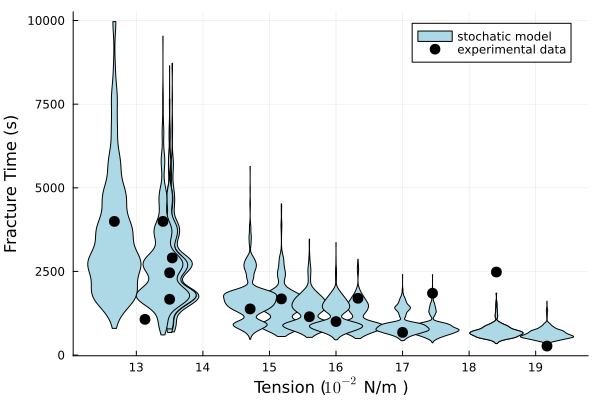

In [6]:
gamma_high = dataframe.gamma_high[dataframe.label .== 2]
expt_t = dataframe.t_gamma_high[dataframe.label .== 2]

violin(stack([gamma_high[:2]])' .* 100, stack(fracture_stochastic_cycle[:2]), label="stochatic model", color=:lightblue)
violin!(stack([gamma_high[2:end]])' .* 100, stack(fracture_stochastic_cycle[2:end]), label="", color=:lightblue)
scatter!(gamma_high.*100, expt_t, label="experimental data", xlabel="Tension (\$10^{-2}\$ N/m )", ylabel="Fracture Time (s)", color=:black, marker=:circle, markersize=6)
# savefig("exp_sim_cycles_violin.svg")

# SM 9

In [17]:
using DelimitedFiles
using Plots
using Measures
using StatsBase
using DataFrames
using StatsPlots; gr()

k_on_0 = 3.47e-4
k_off_0 = 2.68e-4 
f_1e = 2.49e-1

# import utility functions
include("src/utils.jl");

# import functions that help calculate stability equilibria
include("src/f_vectors_k_vectors_nvectors.jl");
# This function return variables that act as look-up tables for stability that can be used by functions of f_vectors_k_vectors_nvectors.jl
K, F, n_stable_store, n_unstable_store = setup_stores(k_off_0 / k_on_0);

# import functions that define loading patterns
include("src/loading_patterns.jl");

# import functions that define the analytical model
include("src/analytical_model.jl");

# import functions that define the stochastic model
include("src/stochastic_model.jl");


fracture_duration = 5000
recovery_duration = 3000
gamma_high = range(0.086, 0.3, length=10)
gamma_low = range(0.00, 0.07, length=10);

Number of threads: 20


In [21]:
# stochastic fracture time
num_sim = 100

# base case
n_bonds = 100
time_to_fracture_stochastic = get_fracture_time_stochastic.(gamma_high, k_on_0, k_off_0, f_1e, fracture_duration, nothing, num_sim, n_bonds, false);

p1 = setup_fig()
means = [mean(x) for x in time_to_fracture_stochastic]
stds  = [std(x)  for x in time_to_fracture_stochastic]
p1 = plot!(p1, gamma_high, means, label="number of bonds = 100", ribbon=stds, linewidth=3)
p1 = plot!(p1, xlabel="Tension (Nm^-1)", ylabel="Time (s)", legend=:topright, title="", titlefontsize=16, size=(600, 400), ylims=(0, 4000))
# scatter individual points
for i in 1:length(gamma_high)
    scatter!(p1, fill(gamma_high[i], num_sim), time_to_fracture_stochastic[i], color=:black, alpha=1., label="", markersize=2)
end


# less bonds
n_bonds = 10
time_to_fracture_stochastic = get_fracture_time_stochastic.(gamma_high, k_on_0, k_off_0, f_1e, fracture_duration, nothing, num_sim, n_bonds, false);

p2 = setup_fig()
means = [mean(x) for x in time_to_fracture_stochastic]
stds  = [std(x)  for x in time_to_fracture_stochastic]
p2 = plot!(p2, gamma_high, means, label="number of bonds = 10", ribbon=stds, linewidth=3)
p2 = plot!(p2, xlabel="Tension (Nm^-1)", ylabel="Time (s)", legend=:topright, title="", titlefontsize=16, size=(600, 400), ylims=(0, 4000))
# scatter individual points
for i in 1:length(gamma_high)
    scatter!(p2, fill(gamma_high[i], num_sim), time_to_fracture_stochastic[i], color=:black, alpha=1., label="", markersize=2)
end


# more bonds
n_bonds = 1000
time_to_fracture_stochastic = get_fracture_time_stochastic.(gamma_high, k_on_0, k_off_0, f_1e, fracture_duration, nothing, num_sim, n_bonds, false);

p3 = setup_fig()
means = [mean(x) for x in time_to_fracture_stochastic]
stds  = [std(x)  for x in time_to_fracture_stochastic]
p3 = plot!(p3, gamma_high, means, label="number of bonds = 1000", ribbon=stds, linewidth=3)
p3 = plot!(p3, xlabel="Tension (Nm^-1)", ylabel="Time (s)", legend=:topright, title="", titlefontsize=16, size=(600, 400), ylims=(0, 4000))
# scatter individual points
for i in 1:length(gamma_high)
    scatter!(p3, fill(gamma_high[i], num_sim), time_to_fracture_stochastic[i], color=:black, alpha=1., label="", markersize=2)
end


┌ Warning: Stochastic simulation did not fracture. Consider increasing duration or changing gamma_high/gamma_low
└ @ Main ~/Documents/JunctionHealing/src/stochastic_model.jl:242


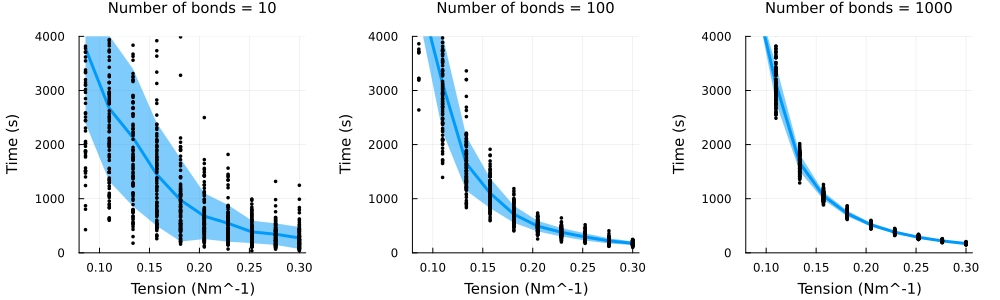

In [22]:
# remove y log scale 
plot!(p1, yscale=:linear, title="Number of bonds = 100", titlefontsize=10)
plot!(p2, yscale=:linear, title = "Number of bonds = 10", titlefontsize=10)
plot!(p3, yscale=:linear, title = "Number of bonds = 1000", titlefontsize=10)

# reduce fontsized of ticks and axis
plot!(p1, guidefontsize=10, tickfontsize=8)
plot!(p2, guidefontsize=10, tickfontsize=8)
plot!(p3, guidefontsize=10, tickfontsize=8)

plot(p2, p1, p3, layout=(1,3), size=(1000, 300), margin=5Plots.mm, legend=false)
# savefig("img/SM_fracture_time_vs_number_of_bonds_fracture.svg")

# SM 10

In [24]:
using Plots

function get_recovery_time_stochastic_individual(gamma_low, k_on_0, k_off_0, f_1e, duration, is_forth_regime, return_bond_info=false, dt = nothing, num_sim = 100, prct = 0.95, n_bonds = 100)    
    n = n_bonds # number of bonds
    l = 1
    if dt == nothing
        n_timesteps = duration*5
        dt = duration/n_timesteps
    else
        n_timesteps = Int(round(duration/dt))
    end

    loading_recovery = constant_loading(gamma_low)
    tension_bond = gamma_low*n*l
    model = SlipBondModel((k_on_0=k_on_0,), (k_off_0=k_off_0, f_1e=f_1e)) 
    k_sim = k_off_0/k_on_0
    f_sim = gamma_low/f_1e

    n_stable, n_unstable = critical_n(k_off_0/k_on_0, gamma_low/f_1e, K, F, n_stable_store, n_unstable_store, true)
    if is_forth_regime
        f_critical, n_critical = critical_f_vector(k_off_0/k_on_0, K, F, n_stable_store, n_unstable_store)
        n_init = n_critical
    else
        n_init = n_unstable + 0.01
    end
    if (n_init < n_unstable) || (n_init > n_stable)
        println("Warning: n_init should be between $n_unstable and $n_stable")
    end


    idx_missing = 1:num_sim
    recovery_time = zeros(num_sim)
    bond_memories = zeros(num_sim, n_timesteps+1)
    @threads for sim in idx_missing 
        x = Cluster(n, l, model, :force_global)
        x = initialise_bonds_state(x, n_init)
        ## Run the Montecarlo simulation until it breaks or it reaches the maximum number of iterations
        state, not_used, recovery_time[sim], step, bond_memories[sim,:] = runcluster_with_bond_history(x, tension_bond, dt, max_steps = n_timesteps, verbose=true, return_bond_history=true)
    end

    # find simulations that did not break
    idx_recovered = bond_memories[:,end] .== bond_memories[:,end]
    pct_recovery = 100*sum(idx_recovered)/num_sim

    # find mean signal of recovered simulations
    mean_signal = mean_along_dim1_ignore_nan(bond_memories)     # bond_mories: [num_sim x n_timesteps]
    std_signal = std_along_dim1_ignore_nan(bond_memories)
    
    t = range(0, stop=duration, length=n_timesteps+1)
    recoveries = - bond_memories .+ n_stable*n
    recoveries = recoveries ./ recoveries[1, 1]  # normalize the recovery curve

    timescales = zeros(size(recoveries, 1))
    for i in 1:size(recoveries, 1)
        if idx_recovered[i]
            # println("pct done: $(100*i/size(recoveries, 1))")
            if length(recoveries[i,:]) > 1
                model_for_fit(x, p) = exp.(-p[1] .* x)
                fit = LsqFit.curve_fit(model_for_fit, t, recoveries[i,:], [0.1])
                timescales[i] = 1 / fit.param[1]
            else
                println("Recovery curve is too short to fit an exponential decay")
            end
        else
            timescales[i] = duration
        end
    end
    
    recovery_time = mean(log(1/(1-prct)) .* timescales)

    if return_bond_info == true
        return recovery_time, timescales, pct_recovery, bond_memories
    else
        return recovery_time
    end
end

is_forth_regime = true
gamma_low_stochastic = range(0.0, 0.08, length=15);
recovery_duration_stochastic = 8000
prct = 0.95
stochastic_recovery = zeros(length(gamma_low_stochastic))

num_sim = 100
timescales = zeros(num_sim, length(gamma_low_stochastic))


# base
n_bonds = 100
temp = get_recovery_time_stochastic_individual.(gamma_low_stochastic, k_on_0, k_off_0, f_1e, recovery_duration_stochastic, is_forth_regime, true, 1.0, num_sim, prct, n_bonds)
stochastic_recovery[:] = [x[1] for x in temp]
timescales[:,:] = hcat([x[2] for x in temp]...)
plot_timescale = timescales
plot_timescale[plot_timescale .< 0] .= 0
scaled_timescale = log(1/(1-prct)) .*plot_timescale[:,:]'
means = mean(log(1/(1-prct)) .* plot_timescale, dims = 1)[1, :]
stds = std(log(1/(1-prct)) .* plot_timescale, dims = 1)[1, :]
p1 = plot(gamma_low_stochastic, means, label="", ribbon=stds, linewidth=3)
plot!(p1, xlabel="Tension (Nm^-1)", ylabel="Time (s)", legend=:topleft, title="", titlefontsize=16, size=(600, 400))
scatter!(p1, gamma_low_stochastic, scaled_timescale, label="", markersize=2, markerstrokewidth=1., markerstrokealpha=1.0, color="black")
max_y = maximum(scaled_timescale)

# less bonds
n_bonds = 10
temp = get_recovery_time_stochastic_individual.(gamma_low_stochastic, k_on_0, k_off_0, f_1e, recovery_duration_stochastic, is_forth_regime, true, 1.0, num_sim, prct, n_bonds)
stochastic_recovery[:] = [x[1] for x in temp]
timescales[:,:] = hcat([x[2] for x in temp]...)
plot_timescale = timescales
plot_timescale[plot_timescale .< 0] .= 0
scaled_timescale = log(1/(1-prct)) .*plot_timescale[:,:]'
means = mean(log(1/(1-prct)) .* plot_timescale, dims = 1)[1, :]
stds = std(log(1/(1-prct)) .* plot_timescale, dims = 1)[1, :]
p2 = plot(gamma_low_stochastic, means, label="", ribbon=stds, linewidth=3)
plot!(p2, xlabel="Tension (Nm^-1)", ylabel="Time (s)", legend=:topleft, title="", titlefontsize=16, size=(600, 400))
scatter!(p2, gamma_low_stochastic, scaled_timescale, label="", markersize=2, markerstrokewidth=1., markerstrokealpha=1.0, color="black")
max_y = maximum(vcat(max_y, maximum(scaled_timescale)))

# more bonds
n_bonds = 1000
temp = get_recovery_time_stochastic_individual.(gamma_low_stochastic, k_on_0, k_off_0, f_1e, recovery_duration_stochastic, is_forth_regime, true, 1.0, num_sim, prct, n_bonds)
stochastic_recovery[:] = [x[1] for x in temp]
timescales[:,:] = hcat([x[2] for x in temp]...)
plot_timescale = timescales
plot_timescale[plot_timescale .< 0] .= 0
scaled_timescale = log(1/(1-prct)) .*plot_timescale[:,:]'
means = mean(log(1/(1-prct)) .* plot_timescale, dims = 1)[1, :]
stds = std(log(1/(1-prct)) .* plot_timescale, dims = 1)[1, :]
p3 = plot(gamma_low_stochastic, means, label="", ribbon=stds, linewidth=3)
plot!(p3, xlabel="Tension (Nm^-1)", ylabel="Time (s)", legend=:topleft, title="", titlefontsize=16, size=(600, 400))
scatter!(p3, gamma_low_stochastic, scaled_timescale, label="", markersize=2, markerstrokewidth=1., markerstrokealpha=1.0, color="black")
max_y = maximum(vcat(max_y, maximum(scaled_timescale)))

Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction

4.027448347603617e6

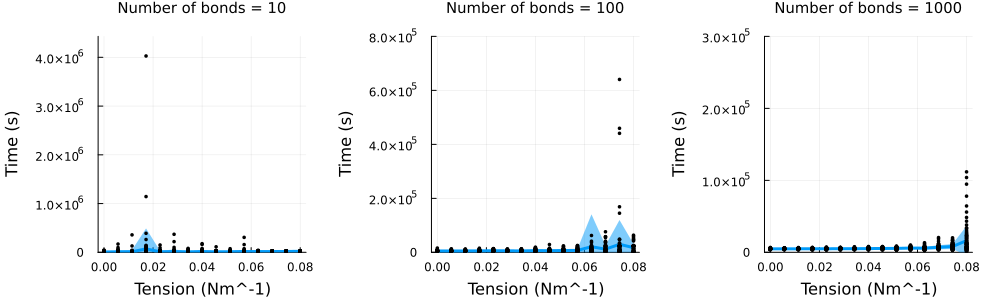

In [25]:
ylims!(p1, (0, 8e5))
ylims!(p2, (0, max_y*1.1))
ylims!(p3, (0, 3e5))

# remove y log scale 
plot!(p1, yscale=:linear, title="Number of bonds = 100", titlefontsize=10)
plot!(p2, yscale=:linear, title = "Number of bonds = 10", titlefontsize=10)
plot!(p3, yscale=:linear, title = "Number of bonds = 1000", titlefontsize=10)

plot(p2, p1, p3, layout=(1,3), size=(1000, 300), margin=5Plots.mm)
# savefig("img/SM_recovery_time_vs_number_of_bonds_recovery.svg")

# SM 11

In [1]:
k_on_0 = 3.47e-4
k_off_0 = 2.68e-4 
f_1e = 2.49e-1

# import utility functions
include("src/utils.jl");

# import functions that help calculate stability equilibria
include("src/f_vectors_k_vectors_nvectors.jl");
# This function return variables that act as look-up tables for stability that can be used by functions of f_vectors_k_vectors_nvectors.jl
K, F, n_stable_store, n_unstable_store = setup_stores(k_off_0 / k_on_0);

# import functions that define loading patterns
include("src/loading_patterns.jl");

# import functions that define the analytical model
include("src/analytical_model.jl");

# import functions that define the stochastic model
include("src/stochastic_model.jl");

recovery_duration = 40000
gamma_low = range(0.000, 0.084, length=20);

Number of threads: 20


In [2]:
f_critical, n_critical = critical_f_vector(k_off_0/k_on_0, K, F, n_stable_store, n_unstable_store)
n_init = n_critical

out = get_recovery_time_stochastic.(gamma_low, k_on_0, k_off_0, f_1e, recovery_duration, true, true, 1.0, 1000, 100)
pct_broken = [100 - o[2] for o in out];


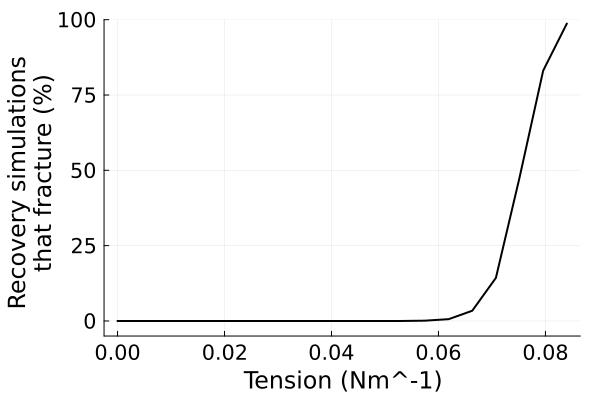

In [3]:
setup_fig()
plot!(gamma_low, pct_broken, linewidth=2, legend=:none, color="black")
plot!(xlabel="Tension (Nm^-1)", ylabel="Recovery simulations \n that fracture (%)", title="", titlefontsize=16, size=(600, 400))
ylims!(-5, 100)
# savefig("img/recovery_pct_broken.svg")

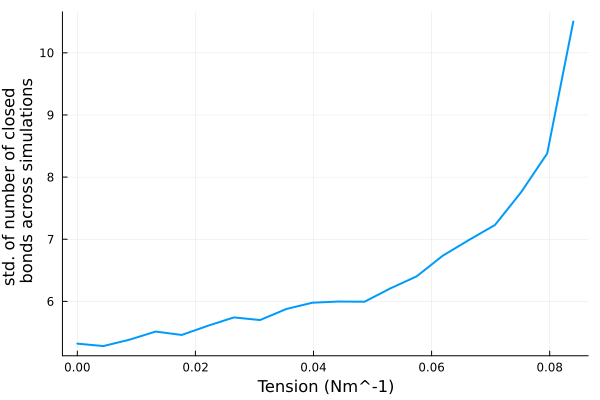

In [4]:
bond_memories_std = [maximum(x for x in std_along_dim1_ignore_nan(o[3])) for o in out];
plot(gamma_low, bond_memories_std, label="", linewidth=2)
plot!(xlabel="Tension (Nm^-1)", ylabel="std. of number of closed \n bonds across simulations", legend=false, title="", titlefontsize=16, size=(600, 400))
# savefig("img/recovery_std.svg")

# SM 12

In [ ]:
k_on_0 = 3.47e-4
k_off_0 = 2.68e-4 
f_1e = 2.49e-1

# import utility functions
include("src/utils.jl");

# import functions that help calculate stability equilibria
include("src/f_vectors_k_vectors_nvectors.jl");
# This function return variables that act as look-up tables for stability that can be used by functions of f_vectors_k_vectors_nvectors.jl
K, F, n_stable_store, n_unstable_store = setup_stores(k_off_0 / k_on_0);

# import functions that define loading patterns
include("src/loading_patterns.jl");

# import functions that define the analytical model
include("src/analytical_model.jl");

# import functions that define the stochastic model
include("src/stochastic_model.jl");

function get_recovery_time_stochastic_infinite_time_for_fracture(gamma_low, k_on_0, k_off_0, f_1e, duration, is_forth_regime, return_bond_info=false, dt = nothing, num_sim = 100, n=100)    
    l = 1
    if isnothing(dt)
        n_timesteps = duration*5
        dt = duration/n_timesteps
    else
        n_timesteps = Int(round(duration/dt))
    end

    tension_bond = gamma_low*n*l
    model = SlipBondModel((k_on_0=k_on_0,), (k_off_0=k_off_0, f_1e=f_1e)) 

    n_stable, n_unstable = critical_n(k_off_0/k_on_0, gamma_low/f_1e, K, F, n_stable_store, n_unstable_store, true)
    if is_forth_regime  # default initialisation
        _, n_critical = critical_f_vector(k_off_0/k_on_0, K, F, n_stable_store, n_unstable_store)
        n_init = n_critical
    else
        if n_unstable != n_unstable # check if n_unstable is NaN then set to zero
            n_unstable = 0
        end
        n_init = n_unstable + 0.01  # start slightly above unstable equilibrium
    end
    if (n_init < n_unstable) || (n_init > n_stable)
        println("Warning: n_init should be between $n_unstable and $n_stable")
    end


    idx_missing = 1:num_sim
    recovery_time = zeros(num_sim)
    bond_memories = zeros(num_sim, n_timesteps+1)
    @threads for sim in idx_missing 
        x = Cluster(n, l, model, :force_global)
        x = initialise_bonds_state(x, n_init)
        _, _, recovery_time[sim], _, bond_memories[sim,:] = runcluster_with_bond_history(x, tension_bond, dt, max_steps = n_timesteps, verbose=false, return_bond_history=true)
    end
    
    # find simulations that did not break
    idx_recovered = bond_memories[:,end] .== bond_memories[:,end]
    pct_recovery = 100*sum(idx_recovered)/num_sim
    # check if there are any simulations that recovered
    if pct_recovery == 0.
        println("No simulations recovered")        
        return NaN
    # elseif pct_recovery < 100
    #     println("Warning: All simulations did not recover, only $pct_recovery %")
    end
    
    # overwrite all Nan of bond_memories with 0
    bond_memories = replace!(bond_memories, NaN => n_init * n)

    # find mean signal of recovered simulations
    mean_signal = mean_along_dim1_ignore_nan(bond_memories)     # bond_mories: [num_sim x n_timesteps]
    std_signal = std_along_dim1_ignore_nan(bond_memories)

    # check if initialisation is too close to the stable number of bonds
    if (n_stable - n_init) < std_signal[1,end]/n
        println("Warning: the initial number of bonds is too close to the stable number of bonds (less than 1 std ($(n_stable-std_signal[1,end]/n)) away)")
    end

    # Fit exponential to the recovery curve to find the recovery time
    t = range(0, stop=duration, length=n_timesteps+1)
    # transform signal to be able to fit an exponential decay
    recovery_curve = - mean_signal .+ n_stable*n
    recovery_curve = recovery_curve ./ recovery_curve[1]
    if length(recovery_curve) > 1
        model_for_fit(x, p) = exp.(-p[1] .* x)
        fit = LsqFit.curve_fit(model_for_fit, t, recovery_curve, [0.1])
        recovery_time = 1 / fit.param[1]
    else
        recovery_time = 0
    end
    
    if return_bond_info == true
        return recovery_time, pct_recovery, bond_memories
    else
        return recovery_time
    end
end

Number of threads: 20


get_recovery_time_stochastic_infinite_time_for_fracture (generic function with 5 methods)

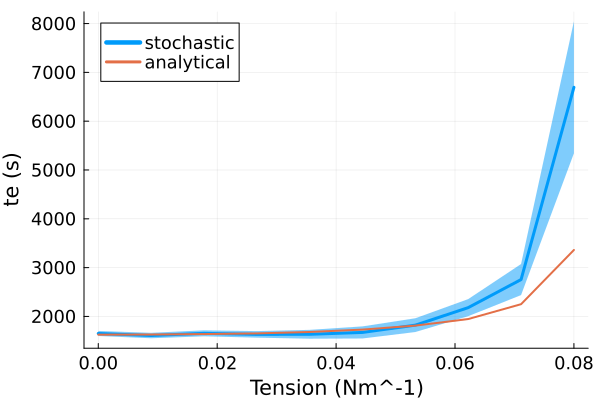

In [49]:
duration = 10000
gamma_low = range(0.0, 0.08, length=10);
dt = 3.0

# analytical recovery time
time_to_recovery = get_recovery_time.(gamma_low, k_on_0, k_off_0, f_1e, duration, true, dt);

# stochastic recovery time
num_sim = 100 # number of simulations to run for each tension value
n = 100
repeats = 5
stochastic_recovery = zeros(repeats, length(gamma_low))
for i = 1:repeats
    recovery_time = get_recovery_time_stochastic_infinite_time_for_fracture.(gamma_low, k_on_0, k_off_0, f_1e, duration, true, false, dt, num_sim, n);
    stochastic_recovery[i,:] = [x[1] for x in recovery_time]
end

setup_fig()
means = mean(stochastic_recovery, dims=1) |> vec
stds  = std(stochastic_recovery, dims=1) |> vec
plot(gamma_low, means, label="stochastic", ribbon=stds, linewidth=3)
plot!(gamma_low, time_to_recovery, label="analytical", linewidth=2)
plot!(xlabel="Tension (Nm^-1)", ylabel="te (s)", legend=:topleft, title="", tickfontsize=12, guidefontsize=14, legendfontsize=12, size=(600, 400))

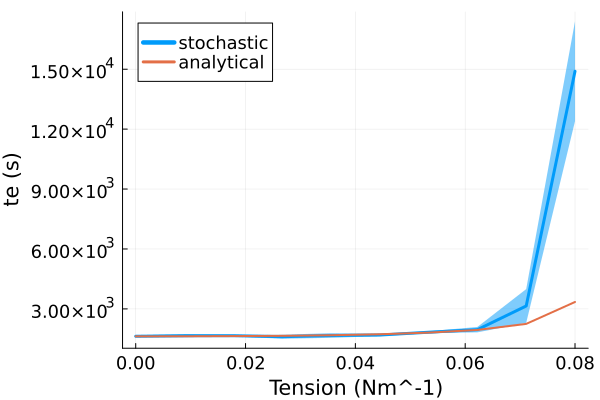

In [50]:
duration = 20000
gamma_low = range(0.0, 0.08, length=10);
dt = 3.0

# analytical recovery time
time_to_recovery = get_recovery_time.(gamma_low, k_on_0, k_off_0, f_1e, duration, true, dt);

# stochastic recovery time
num_sim = 100 # number of simulations to run for each tension value
n = 100
repeats = 5
stochastic_recovery = zeros(repeats, length(gamma_low))
for i = 1:repeats
    recovery_time = get_recovery_time_stochastic_infinite_time_for_fracture.(gamma_low, k_on_0, k_off_0, f_1e, duration, true, false, dt, num_sim, n);
    stochastic_recovery[i,:] = [x[1] for x in recovery_time]
end

setup_fig()
means = mean(stochastic_recovery, dims=1) |> vec
stds  = std(stochastic_recovery, dims=1) |> vec
plot(gamma_low, means, label="stochastic", ribbon=stds, linewidth=3)
plot!(gamma_low, time_to_recovery, label="analytical", linewidth=2)
plot!(xlabel="Tension (Nm^-1)", ylabel="te (s)", legend=:topleft, title="", tickfontsize=12, guidefontsize=14, legendfontsize=12, size=(600, 400))

# SM 13

In [16]:
# Model parameters used throughout the notebooks
k_on_0 = 3.47e-4
k_off_0 = 2.68e-4 
f_1e = 2.49e-1

# import utility functions
include("src/utils.jl");

# import functions that help calculate stability equilibria
include("src/f_vectors_k_vectors_nvectors.jl");
# This function return variables that act as look-up tables for stability that can be used by functions of f_vectors_k_vectors_nvectors.jl
K, F, n_stable_store, n_unstable_store = setup_stores(k_off_0 / k_on_0);

# import functions that define loading patterns
include("src/loading_patterns.jl");

# import functions that define the analytical model
include("src/analytical_model.jl");

# import functions that define the stochastic model
include("src/stochastic_model.jl");

gamma_high = collect(range(0.09, 0.12, length=2)) 
gamma_low = collect(range(0.00, 0.0525, length=4)); 
duration = 20000

# get time to recovery
time_to_recovery = get_recovery_time.(gamma_low, k_on_0, k_off_0, f_1e, duration, false)

# get time to fracture
time_to_fracture = zeros(length(gamma_high), length(gamma_low))
for (idx, g_l) in enumerate(gamma_low)
    time_to_fracture[:,idx] = get_fracture_time.(gamma_high, k_on_0, k_off_0, f_1e, duration, g_l)
end

# proportional ranges of high and low time periods relative to their respective timescales
time_high_ratio = range(0.01, 1.5, length=40)
time_low_ratio = range(0.01, 4.5, length=40)

# run simulations over grid of time ratios
for g_h in 1:length(gamma_high)
    for g_l in 1:length(gamma_low)
        # run cyclic simulations over grid of time ratios
        cyclic_time_to_fracture = zeros(length(time_high_ratio), length(time_low_ratio))
        for t1 in 1:length(time_high_ratio)
            @threads for t2 in 1:length(time_low_ratio)
                # caluclate duration to spend 20x time_to_fracture at high tension for current t_high and t_low
                t_high = time_high_ratio[t1]*time_to_fracture[g_h, g_l]
                t_low = time_low_ratio[t2]*time_to_recovery[g_l]
                objective_time_high = 20 * time_to_fracture[g_h, g_l]
                period = t_high + t_low
                n_periods = ceil(objective_time_high / t_high)
                duration = n_periods * period

                loading = square_cycle_uneven_new(gamma_high[g_h], gamma_low[g_l], t_high, t_low)
                n_stable, n_unstable = critical_n(k_off_0/k_on_0, gamma_low[g_l]/f_1e, K, F, n_stable_store, n_unstable_store, true)
                n_init = n_stable
                sol = solve_dn_dt(n_init, k_on_0, k_off_0, f_1e, loading, duration, 1.0)
                time_of_fracture = find_fracture(sol) 
                cyclic_time_to_fracture[t1, t2] = fracture_to_t_high(time_of_fracture, t_high, t_low)                          
            end
        end

        # rescale data from 0 to 1
        cyclic_time_to_fracture_plot = cyclic_time_to_fracture'
        cyclic_time_to_fracture_plot = (cyclic_time_to_fracture_plot .- time_to_fracture[g_h, g_l]) ./ cyclic_time_to_fracture_plot

        # Plot heatmap
        x = vec(time_high_ratio)
        y = vec(time_low_ratio)
        plot(size=(450, 400), guidefontsize=16, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
        heatmap!(x,y, cyclic_time_to_fracture_plot, color=:viridis, xlabel="\$t_{high}/t^*\$", ylabel="\$t_{low}/t_r\$", cbar=true, clims=(0, 1))
        xlims!(0, maximum(x))
        ylims!(0, maximum(y))

        # save figure
        savefig("figures/SM_11_analytical_gamma_high_$(round(gamma_high[g_h], digits=3))_gamma_low_$(round(gamma_low[g_l], digits=3)).svg")
    end
end

Number of threads: 20


# SM 14

In [81]:
# import utility functions
include("src/utils.jl");

# import functions that help calculate stability equilibria
include("src/f_vectors_k_vectors_nvectors.jl");
# This function return variables that act as look-up tables for stability that can be used by functions of f_vectors_k_vectors_nvectors.jl
K, F, n_stable_store, n_unstable_store = setup_stores(k_off_0 / k_on_0);

# import functions that define loading patterns
include("src/loading_patterns.jl");

# import functions that define the analytical model
include("src/analytical_model.jl");

# import functions that define the stochastic model
include("src/stochastic_model.jl");
### Analytical model: Calculate recovery timescale, fracture timescale and simulate maps
gamma_high = 0.15
gamma_low = 0.015
duration = 20000;


Number of threads: 20


In [66]:
# Model parameters used throughout the notebooks
k_on_0 = 3.47e-4
k_off_0 = 2.68e-4 
f_1e = 2.49e-1

# get time to recovery
time_to_recovery = get_recovery_time(gamma_low, k_on_0, k_off_0, f_1e, duration, false)

# get time to fracture
time_to_fracture = get_fracture_time(gamma_high, k_on_0, k_off_0, f_1e, duration, gamma_low)

# get stable and unstable n at low gamma to initialize cyclic simulations
n_stable, n_unstable = critical_n(k_off_0/k_on_0, gamma_low/f_1e, K, F, n_stable_store, n_unstable_store, true)
n_init = n_stable

# proportional ranges of high and low time periods relative to their respective timescales
time_high_ratio = range(0.01, 1.5, length=40)
time_low_ratio = range(0.01, 4.5, length=40)

# run simulations over grid of time ratios
cyclic_time_to_fracture = zeros(length(time_high_ratio), length(time_low_ratio))
@suppress for t1 in 1:length(time_high_ratio)
    @threads for t2 in 1:length(time_low_ratio)
        # caluclate duration to spend 20x time_to_fracture at high tension for current t_high and t_low
        t_high = time_high_ratio[t1]*time_to_fracture
        t_low = time_low_ratio[t2]*time_to_recovery
        objective_time_high = 20 * time_to_fracture
        period = t_high + t_low
        n_periods = ceil(objective_time_high / t_high)
        duration = n_periods * period

        loading = square_cycle_uneven_new(gamma_high, gamma_low, time_high_ratio[t1]*time_to_fracture, time_low_ratio[t2]*time_to_recovery)
        sol = solve_dn_dt(n_init, k_on_0, k_off_0, f_1e, loading, duration, 1.0)
        fracture_time = find_fracture(sol)
        cyclic_time_to_fracture[t1, t2] = fracture_to_t_high(fracture_time, t_high, t_low) # find how long spent at high tension before fracture                            
    end
end

In [67]:
# Model parameters used throughout the notebooks
k_on_0 = 3.47e-4 * 2
k_off_0 = 2.68e-4 * 2
f_1e = 2.49e-1

# get time to recovery
time_to_recovery_2 = get_recovery_time(gamma_low, k_on_0, k_off_0, f_1e, duration, false)

# get time to fracture
time_to_fracture_2 = get_fracture_time(gamma_high, k_on_0, k_off_0, f_1e, duration, gamma_low)

# get stable and unstable n at low gamma to initialize cyclic simulations
n_stable, n_unstable = critical_n(k_off_0/k_on_0, gamma_low/f_1e, K, F, n_stable_store, n_unstable_store, true)
n_init = n_stable

# proportional ranges of high and low time periods relative to their respective timescales
time_high_ratio = range(0.01, 1.5, length=40)
time_low_ratio = range(0.01, 4.5, length=40)

# run simulations over grid of time ratios
cyclic_time_to_fracture_2 = zeros(length(time_high_ratio), length(time_low_ratio))
@suppress for t1 in 1:length(time_high_ratio)
    @threads for t2 in 1:length(time_low_ratio)
        # caluclate duration to spend 20x time_to_fracture at high tension for current t_high and t_low
        t_high = time_high_ratio[t1]*time_to_fracture_2
        t_low = time_low_ratio[t2]*time_to_recovery_2
        objective_time_high = 20 * time_to_fracture_2
        period = t_high + t_low
        n_periods = ceil(objective_time_high / t_high)
        duration = n_periods * period

        loading = square_cycle_uneven_new(gamma_high, gamma_low, time_high_ratio[t1]*time_to_fracture_2, time_low_ratio[t2]*time_to_recovery_2)
        sol = solve_dn_dt(n_init, k_on_0, k_off_0, f_1e, loading, duration, 1.0)
        fracture_time = find_fracture(sol)
        cyclic_time_to_fracture_2[t1, t2] = fracture_to_t_high(fracture_time, t_high, t_low) # find how long spent at high tension before fracture                            
    end
end

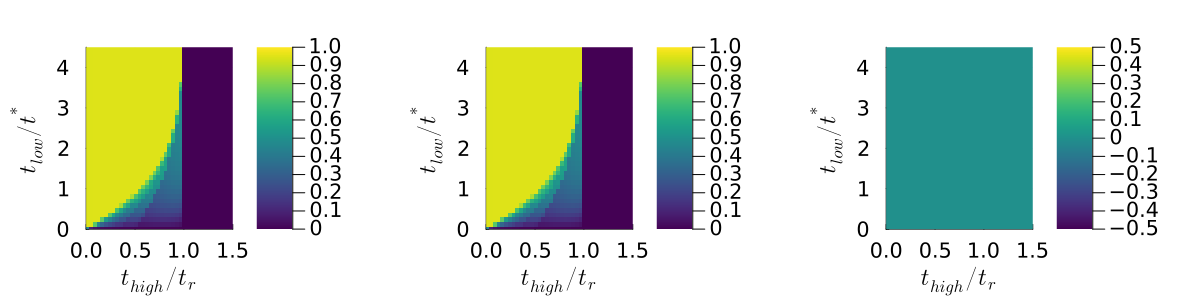

In [ ]:
cyclic_time_to_fracture_plot = adjoint(cyclic_time_to_fracture)
cyclic_time_to_fracture_plot = (cyclic_time_to_fracture_plot .- time_to_fracture) ./ cyclic_time_to_fracture_plot

x = vec(time_high_ratio)
y = vec(time_low_ratio)
p1 = plot(size=(450, 400), guidefontsize=16, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
heatmap!(p1, x,y, cyclic_time_to_fracture_plot, color=:viridis, xlabel="\$t_{high} / t_r\$", ylabel="\$t_{low}/t^*\$", cbar=true, clims=(0, 1))
xlims!(p1, 0, maximum(x))
ylims!(p1, 0, maximum(y))

cyclic_time_to_fracture_plot_2 = adjoint(cyclic_time_to_fracture_2)
cyclic_time_to_fracture_plot_2 = (cyclic_time_to_fracture_plot_2 .- time_to_fracture_2) ./ cyclic_time_to_fracture_plot_2
p2 = plot(size=(450, 400), guidefontsize=16, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
heatmap!(p2, x,y, cyclic_time_to_fracture_plot_2, color=:viridis, xlabel="\$t_{high} / t_r\$", ylabel="\$t_{low}/t^*\$", cbar=true, clims=(0, 1))
xlims!(p2, 0, maximum(x))
ylims!(p2, 0, maximum(y))


difference = abs.(cyclic_time_to_fracture_plot_2 - cyclic_time_to_fracture_plot)
p3 = plot(size=(450, 400), guidefontsize=16, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
heatmap!(p3, x,y, difference, color=:viridis, xlabel="\$t_{high} / t_r\$", ylabel="\$t_{low}/t^*\$", cbar=true, clims=(-0.5, 0.5))
xlims!(p3, 0, maximum(x))
ylims!(p3, 0, maximum(y))

plot(p1,p2, p3, layout=(1,3), size=(1200, 300), margin=10Plots.mm)


# SM 15

In [1]:
using Plots

# import utility functions
include("src/utils.jl");

# import functions that help calculate stability equilibria
include("src/f_vectors_k_vectors_nvectors.jl");

# import functions that define loading patterns
include("src/loading_patterns.jl");

# import functions that define the analytical model
include("src/analytical_model.jl");

# import functions that define the analytical model
include("src/stochastic_model.jl");

function derivative_window(x, y, window)
    # more robust derivative calculator
    l = length(x)
    derivative = zeros(l-window)
    for i in 1:l-window
        x_mean = mean(x[i:i+window])
        y_mean = mean(y[i:i+window])
        numerator = sum((x[i:i+window] .- x_mean).* (y[i:i+window] .- y_mean))
        denominator = sum((x[i:i+window] .- x_mean).^2)
        derivative[i] =  numerator/denominator
    end
    mid_window = Int(round(window/2))
    return derivative, y[mid_window: mid_window + length(derivative)-1]
end


k_on_0 = 3e-3
k_off_0 = 3e-4
f_1e = 0.055
n=100
gamma_high = 0.085     #0.0639349783261087
gamma_low = 0.00
duration = 20000

# This function return variables that act as look-up tables for stability that can be used by functions of f_vectors_k_vectors_nvectors.jl
K, F, n_stable_store, n_unstable_store = setup_stores(k_off_0 / k_on_0);

n_stable, n_unstable = critical_n(k_off_0/k_on_0, gamma_low/f_1e, K, F, n_stable_store, n_unstable_store, true)
if n_unstable != n_unstable
    n_unstable = 0
end

Number of threads: 20


0

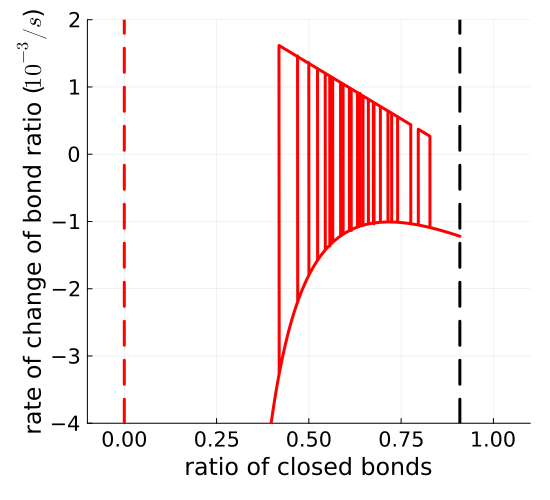

In [7]:
t_h = 100
t_l = 100
loading = square_cycle_uneven_new(gamma_high, gamma_low, t_h, t_l)

# run sim
mean_time_to_recovery = 0
sol = solve_dn_dt(n_stable, k_on_0, k_off_0, f_1e, loading, duration)

# get dt
dt = sol.t[2] - sol.t[1]

# get the bond ratio before fracture
fracture = find_fracture(sol)
nt = sol.n_ratio[sol.t .< fracture]

# Calculate the rate of change of the number of bonds with respect to time
dn_dt_values = diff(nt, dims=1) ./dt

# # Plot the rate of change of number of bonds with respect to time over n_ratio
plot(nt[2:20:end], dn_dt_values[1:20:end]*1000,  xlabel="ratio of closed bonds", label="", ylabel="rate of change of bond ratio (\$10^{-3} / s\$)", title="", color="red", size=(550, 500),linewidth=3, legend=:topright, guidefontsize=16, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
xlims!(-0.1, 1.1)
ylims!(-4, 2)
vline!([n_stable], label="", linestyle=:dash, linewidth=3, color="black")
vline!([n_unstable], label="", linestyle=:dash, linewidth=3, color="red")
# savefig("img/Y1_Phase_plot_gh_$(gamma_high)_gl_$(gamma_low)_th_$(t_h)_tl_$(t_l).svg")


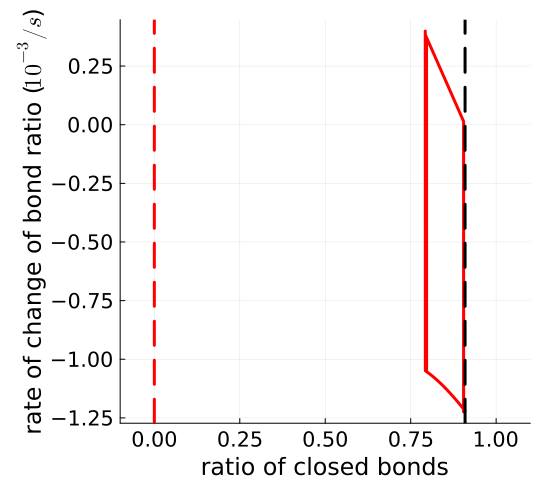

In [8]:
t_h = 100
t_l = 1000
loading = square_cycle_uneven_new(gamma_high, gamma_low, t_h, t_l)

# run sim
mean_time_to_recovery = 0
sol = solve_dn_dt(n_stable, k_on_0, k_off_0, f_1e, loading, duration)

# get dt
dt = sol.t[2] - sol.t[1]

# get the bond ratio before fracture
fracture = find_fracture(sol)
nt = sol.n_ratio[sol.t .< fracture]

# Calculate the rate of change of the number of bonds with respect to time
dn_dt_values = diff(nt, dims=1) ./dt

# Plot the rate of change of number of bonds with respect to time over n_ratio
plot(nt[2:20:end], dn_dt_values[1:20:end]*1000,  xlabel="ratio of closed bonds", label="", ylabel="rate of change of bond ratio (\$10^{-3}/s\$)", title="", color="red", size=(550, 500),linewidth=3, legend=:topright, guidefontsize=16, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
xlims!(-0.1, 1.1)
# ylims!(-4, 2)
vline!([n_stable], label="", linestyle=:dash, linewidth=3, color="black")
vline!([n_unstable], label="", linestyle=:dash, linewidth=3, color="red")
# savefig("img/Y1_Phase_plot_gh_$(gamma_high)_gl_$(gamma_low)_th_$(t_h)_tl_$(t_l).svg")


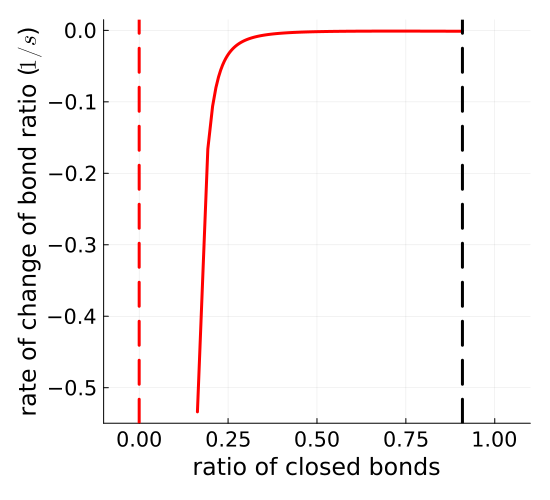

In [10]:
t_h = 1000
t_l = 100
loading = square_cycle_uneven_new(gamma_high, gamma_low, t_h, t_l)

# run sim
mean_time_to_recovery = 0
sol = solve_dn_dt(n_stable, k_on_0, k_off_0, f_1e, loading, duration)

# get dt
dt = sol.t[2] - sol.t[1]

# get the bond ratio before fracture
fracture = find_fracture(sol)
nt = sol.n_ratio[sol.t .< fracture]

# Calculate the rate of change of the number of bonds with respect to time
dn_dt_values = diff(nt, dims=1) ./dt

# # Plot the rate of change of number of bonds with respect to time over n_ratio
plot(nt[2:10:end], dn_dt_values[1:10:end],  xlabel="ratio of closed bonds", label="", ylabel="rate of change of bond ratio (\$1/s\$)", title="", color="red", size=(550, 500),linewidth=3, legend=:topright, guidefontsize=16, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
xlims!(-0.1, 1.1)
# ylims!(-4, 2)
vline!([n_stable], label="", linestyle=:dash, linewidth=3, color="black")
vline!([n_unstable], label="", linestyle=:dash, linewidth=3, color="red")
# savefig("img/Y1_Phase_plot_gh_$(gamma_high)_gl_$(gamma_low)_th_$(t_h)_tl_$(t_l).svg")

Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken


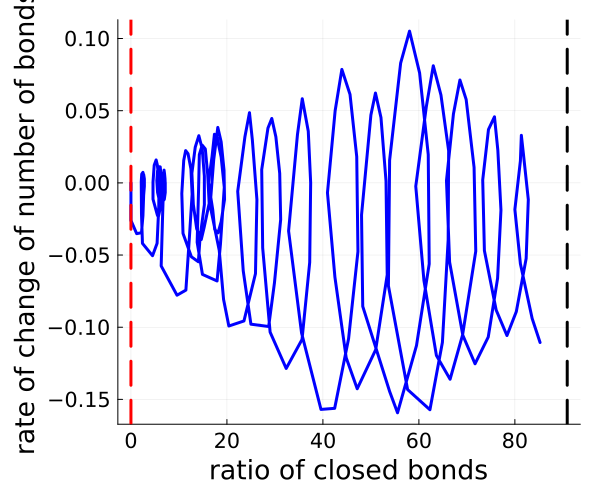

In [ ]:
n=100
l=1
num_sim = 20
dt  = 1.0

t_h = 100
t_l = 100
loading = square_cycle_uneven_new(gamma_high, gamma_low, t_h, t_l)
tension_bond, n_timesteps = loading_stochastic_model(loading, n, duration, dt)
n_stable, _ = critical_n(k_off_0/k_on_0, gamma_low/f_1e, K, F, n_stable_store, n_unstable_store, true)
bond_memories = zeros(num_sim,length(tension_bond)+1)
for idx in 1:num_sim
    model = SlipBondModel((k_on_0=3e-3,), (k_off_0=3e-4, f_1e=0.055)) 
    x = Cluster(n, l, model, :force_global)
    x = initialise_bonds_state(x, n_stable)
    _, _, _, _, bond_memories[idx,:] = runcluster_with_bond_history(x, tension_bond, dt; max_steps = n_timesteps, verbose=true, return_bond_history=true)
end

bond_memories[bond_memories .!= bond_memories] .= 0
bond_memories_mean = mean(bond_memories, dims=1)[1,:]
derivative, bond_memories_derivative = derivative_window(LinRange(0, duration, n_timesteps+1), bond_memories_mean, 100)

# Plot the rate of change of number of bonds with respect to time over n_ratio
plot(bond_memories_derivative[1:20:end], derivative[1:20:end],  xlabel="ratio of closed bonds", label="", ylabel="rate of change of number of bonds", title="", color="blue", size=(600, 500),linewidth=3, legend=:topright, guidefontsize=18, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
vline!([n_stable*n], label="", linestyle=:dash, linewidth=3, color="black")
vline!([n_unstable*n], label="", linestyle=:dash, linewidth=3, color="red")
# savefig("Phase_plot_stochastic_gh_$(gamma_high)_gl_$(gamma_low)_th_$(t_h)_tl_$(t_l).svg")

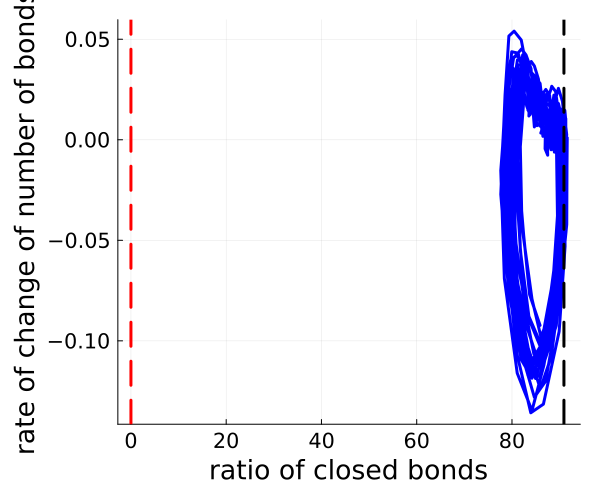

In [6]:
t_h = 100
t_l = 1000
loading = square_cycle_uneven_new(gamma_high, gamma_low, t_h, t_l)
tension_bond, n_timesteps = loading_stochastic_model(loading, n, duration, dt)
n_stable, _ = critical_n(k_off_0/k_on_0, gamma_low/f_1e, K, F, n_stable_store, n_unstable_store, true)
bond_memories = zeros(num_sim,length(tension_bond)+1)
for idx in 1:num_sim
    model = SlipBondModel((k_on_0=3e-3,), (k_off_0=3e-4, f_1e=0.055)) 
    x = Cluster(n, l, model, :force_global)
    x = initialise_bonds_state(x, n_stable)
    _, _, _, _, bond_memories[idx,:] = runcluster_with_bond_history(x, tension_bond, dt; max_steps = n_timesteps, verbose=true, return_bond_history=true)
end

bond_memories[bond_memories .!= bond_memories] .= 0
bond_memories_mean = mean(bond_memories, dims=1)[1,:]
derivative, bond_memories_derivative = derivative_window(LinRange(0, duration, n_timesteps+1), bond_memories_mean, 100)

# Plot the rate of change of number of bonds with respect to time over n_ratio
plot(bond_memories_derivative[1:20:end], derivative[1:20:end],  xlabel="ratio of closed bonds", label="", ylabel="rate of change of number of bonds", title="", color="blue", size=(600, 500),linewidth=3, legend=:topright, guidefontsize=18, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
vline!([n_stable*n], label="", linestyle=:dash, linewidth=3, color="black")
vline!([n_unstable*n], label="", linestyle=:dash, linewidth=3, color="red")
# savefig("Phase_plot_stochastic_gh_$(gamma_high)_gl_$(gamma_low)_th_$(t_h)_tl_$(t_l).svg")

Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken
Junction broken


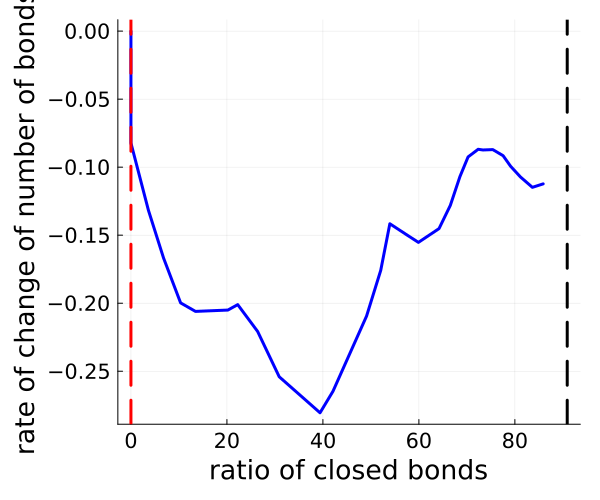

In [7]:
t_h = 1000
t_l = 100
loading = square_cycle_uneven_new(gamma_high, gamma_low, t_h, t_l)
tension_bond, n_timesteps = loading_stochastic_model(loading, n, duration, dt)
n_stable, _ = critical_n(k_off_0/k_on_0, gamma_low/f_1e, K, F, n_stable_store, n_unstable_store, true)
bond_memories = zeros(num_sim,length(tension_bond)+1)
for idx in 1:num_sim
    model = SlipBondModel((k_on_0=3e-3,), (k_off_0=3e-4, f_1e=0.055)) 
    x = Cluster(n, l, model, :force_global)
    x = initialise_bonds_state(x, n_stable)
    _, _, _, _, bond_memories[idx,:] = runcluster_with_bond_history(x, tension_bond, dt; max_steps = n_timesteps, verbose=true, return_bond_history=true)
end

bond_memories[bond_memories .!= bond_memories] .= 0
bond_memories_mean = mean(bond_memories, dims=1)[1,:]
derivative, bond_memories_derivative = derivative_window(LinRange(0, duration, n_timesteps+1), bond_memories_mean, 100)

# Plot the rate of change of number of bonds with respect to time over n_ratio
plot(bond_memories_derivative[1:20:end], derivative[1:20:end],  xlabel="ratio of closed bonds", label="", ylabel="rate of change of number of bonds", title="", color="blue", size=(600, 500),linewidth=3, legend=:topright, guidefontsize=18, tickfontsize=14, legendfontsize=14, margin=3Plots.mm)
vline!([n_stable*n], label="", linestyle=:dash, linewidth=3, color="black")
vline!([n_unstable*n], label="", linestyle=:dash, linewidth=3, color="red")
# savefig("Phase_plot_stochastic_gh_$(gamma_high)_gl_$(gamma_low)_th_$(t_h)_tl_$(t_l).svg")

# SM 16

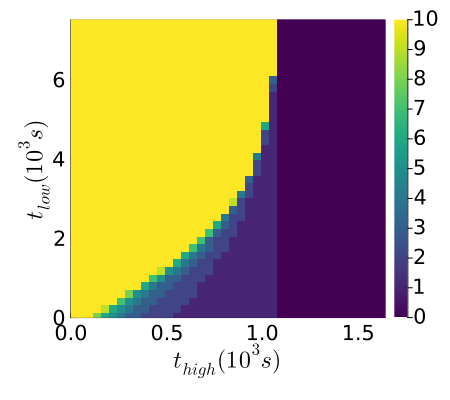

In [ ]:
# Model parameters used throughout the notebooks
k_on_0 = 3.47e-4
k_off_0 = 2.68e-4 
f_1e = 2.49e-1

# import utility functions
include("src/utils.jl");

# import functions that help calculate stability equilibria
include("src/f_vectors_k_vectors_nvectors.jl");
# This function return variables that act as look-up tables for stability that can be used by functions of f_vectors_k_vectors_nvectors.jl
K, F, n_stable_store, n_unstable_store = setup_stores(k_off_0 / k_on_0);

# import functions that define loading patterns
include("src/loading_patterns.jl");

# import functions that define the analytical model
include("src/analytical_model.jl");

# import functions that define the stochastic model
include("src/stochastic_model.jl");
gamma_high = 0.15
gamma_low = 0.015
duration = 20000

# get time to recovery
time_to_recovery = get_recovery_time(gamma_low, k_on_0, k_off_0, f_1e, duration, false)

# get time to fracture
time_to_fracture = get_fracture_time(gamma_high, k_on_0, k_off_0, f_1e, duration, gamma_low)

# get stable and unstable n at low gamma to initialize cyclic simulations
n_stable, n_unstable = critical_n(k_off_0/k_on_0, gamma_low/f_1e, K, F, n_stable_store, n_unstable_store, true)
n_init = n_stable


# proportional ranges of high and low time periods relative to their respective timescales
time_high_ratio = range(0.01, 1.5, length=40)
time_low_ratio = range(0.01, 4.5, length=40)

# run simulations over grid of time ratios
cyclic_time_to_fracture = zeros(length(time_high_ratio), length(time_low_ratio))
objective_time_high = 20 * time_to_fracture
@suppress for t1 in 1:length(time_high_ratio)
    @threads for t2 in 1:length(time_low_ratio)
        # caluclate duration to spend 20x time_to_fracture at high tension for current t_high and t_low
        t_high = time_high_ratio[t1]*time_to_fracture
        t_low = time_low_ratio[t2]*time_to_recovery
        period = t_high + t_low
        n_periods = ceil(objective_time_high / t_high)
        duration = n_periods * period

        loading = square_cycle_uneven_new(gamma_high, gamma_low, time_high_ratio[t1]*time_to_fracture, time_low_ratio[t2]*time_to_recovery)
        sol = solve_dn_dt(n_init, k_on_0, k_off_0, f_1e, loading, duration, 1.0)
        fracture_time = find_fracture(sol)
        cyclic_time_to_fracture[t1, t2] = fracture_time 
    end
end

n_cycles = floor.(cyclic_time_to_fracture' ./ (x' .+ y))
passed_t_high = cyclic_time_to_fracture' .%  (x' .+ y)
in_recovery = float.(passed_t_high .> x')

heatmap!(x./1000,y./1000, n_cycles .+ in_recovery, color=:viridis, xlabel="\$t_{high} (10^3 s)\$", ylabel="\$t_{low} (10^3 s)\$", cbar=true, clims=(0, 10))